This notebook shows:
1. How test function (`data/function.py`) works
2. How TAMO (`model/tamo.py`) predicts
3. How TAMO optimizes: not included in this notebook, since it would be quite slow on cpu; instead, saved regret results will be shown.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
os.chdir(os.path.abspath(".."))


import torch 

from data.function import SyntheticFunction
from data.base.preprocessing import make_range_nested_list
from utils.plot import plot_prediction
from utils.config import get_train_x_range, get_train_y_range, build_tamo, load_checkpoint, remap_checkpoint_keys
from utils.paths import RESULT_PATH
from model.layers import GMMPredictionHead

%reload_ext autoreload
%autoreload 2

/scratch/work/zhangx18/.conda_envs/tamo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cpu"
batch_size = 1
num_grid = 100

expid = "DX12_DY123"

In [3]:
# Load ckpt
exp_path = f"{RESULT_PATH}/TAMO/{expid}"
ckpt = load_checkpoint(exp_path=exp_path, device=device, resume=True)
model_state_dict = ckpt.get("model", {})
if not model_state_dict:
    raise RuntimeError(
        f"Invalid checkpoint loaded from {exp_path}. "
        "Checkpoint is either empty or missing the 'model' key."
    )
model_state_dict = remap_checkpoint_keys(model_state_dict)

# Build model
model = build_tamo()
missing, unexpected = model.load_state_dict(model_state_dict, strict=False)
if missing:
    print(f"[WARNING] Missing keys after checkpoint load:\n  " + "\n  ".join(missing))
if unexpected:
    print(f"[WARNING] Unexpected keys in checkpoint:\n  " + "\n  ".join(unexpected))

print(
    f"--- Model built: TAMO ---\n"
    f"  Config: {model.config}\n"
    f"  Parameters: {sum(p.numel() for p in model.parameters()):,}"
)


model = model.cpu()
model.eval()

--- Model built: TAMO ---
  Config: TAMOConfig(max_x_dim=4, max_y_dim=3, dim_mlp=64, use_missing_marker=False, dim_attn=64, nhead=4, dropout=0.0, num_layers_backbone=4, num_layers_encoder=4, num_layers_decoder=4, ctx_prefix_encoder_layer=True, dim_hidden=128, depth=3, num_components=20, use_ar=False, std_min=0.0001, std_max=1.0, single_mlp=False)
  Parameters: 1,130,301


TAMO(
  (embedder): DimensionWiseEmbedder(
    (mlp_x): Linear(in_features=1, out_features=64, bias=True)
    (mlp_y): Linear(in_features=1, out_features=64, bias=True)
  )
  (encoder): DimensionAgnosticEncoder(
    (in_proj): Identity()
    (out_proj): Identity()
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=256, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (linear2): Linear(in_features=256, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.0, inplace=False)
          (dropout2): Dropout(p=0.0, inplace=False)
        )
      )
    )


## How test function works and how TAMO predicts

In [ ]:
# Init BraninCurrin (BC) function
test_function = SyntheticFunction(function_name="BraninCurrin")
print(
    f"""--- Details ---
        Function:\t{test_function.function_name}
        x dimension:\t{test_function.x_dim}
        y dimension:\t{test_function.y_dim}
        x bounds:\n{test_function.x_bounds}
        y bounds:\n{test_function.y_bounds}
        Max hypervolume:\t{test_function.max_hv:.4f}"""
)

# Range that TAMO trained on! 
target_input_bounds = make_range_nested_list(get_train_x_range(), test_function.x_dim)
target_output_bounds = make_range_nested_list(get_train_y_range(), test_function.y_dim)

--- Details ---
        Function:	BraninCurrin
        x dimension:	2
        y dimension:	2
        x bounds:
tensor([[0., 1.],
        [0., 1.]])
        y bounds:
tensor([[  0.3979, 309.0000],
        [  1.1800,  14.0000]])
        Max hypervolume:	59.3601


In [18]:
x_mask = torch.ones(test_function.x_dim).bool()
y_mask = torch.ones(test_function.y_dim).bool()

# Sample grid datapoints from BC for visualization
x_plot, y_plot, _, _ = test_function.sample(
    input_bounds=target_input_bounds,
    batch_size=batch_size,
    num_subspace_points=num_grid,
    device=device,
    use_grid_sampling=True,
)

y_plot_scaled = test_function.transform_outputs(y_plot, target_output_bounds)

In [19]:
# Sample context datapoints from BC
nc = 30
xc, yc, _, _ = test_function.sample(
    input_bounds=target_input_bounds,
    batch_size=batch_size,
    num_subspace_points=nc,
    device=device,
    use_grid_sampling=True,
)

# NOTE must scale function values for tamo
yc_scaled = test_function.transform_outputs(yc, target_output_bounds)

# get predictions on current observations
out = model.predict(
    x_ctx=xc,
    y_ctx=yc_scaled,
    x_tar=x_plot,
    x_mask=x_mask.unsqueeze(0).expand(batch_size, -1),
    y_mask=y_mask.unsqueeze(0).expand(batch_size, -1),
)
mean = GMMPredictionHead.expected_value(out)
std = GMMPredictionHead.std(out)

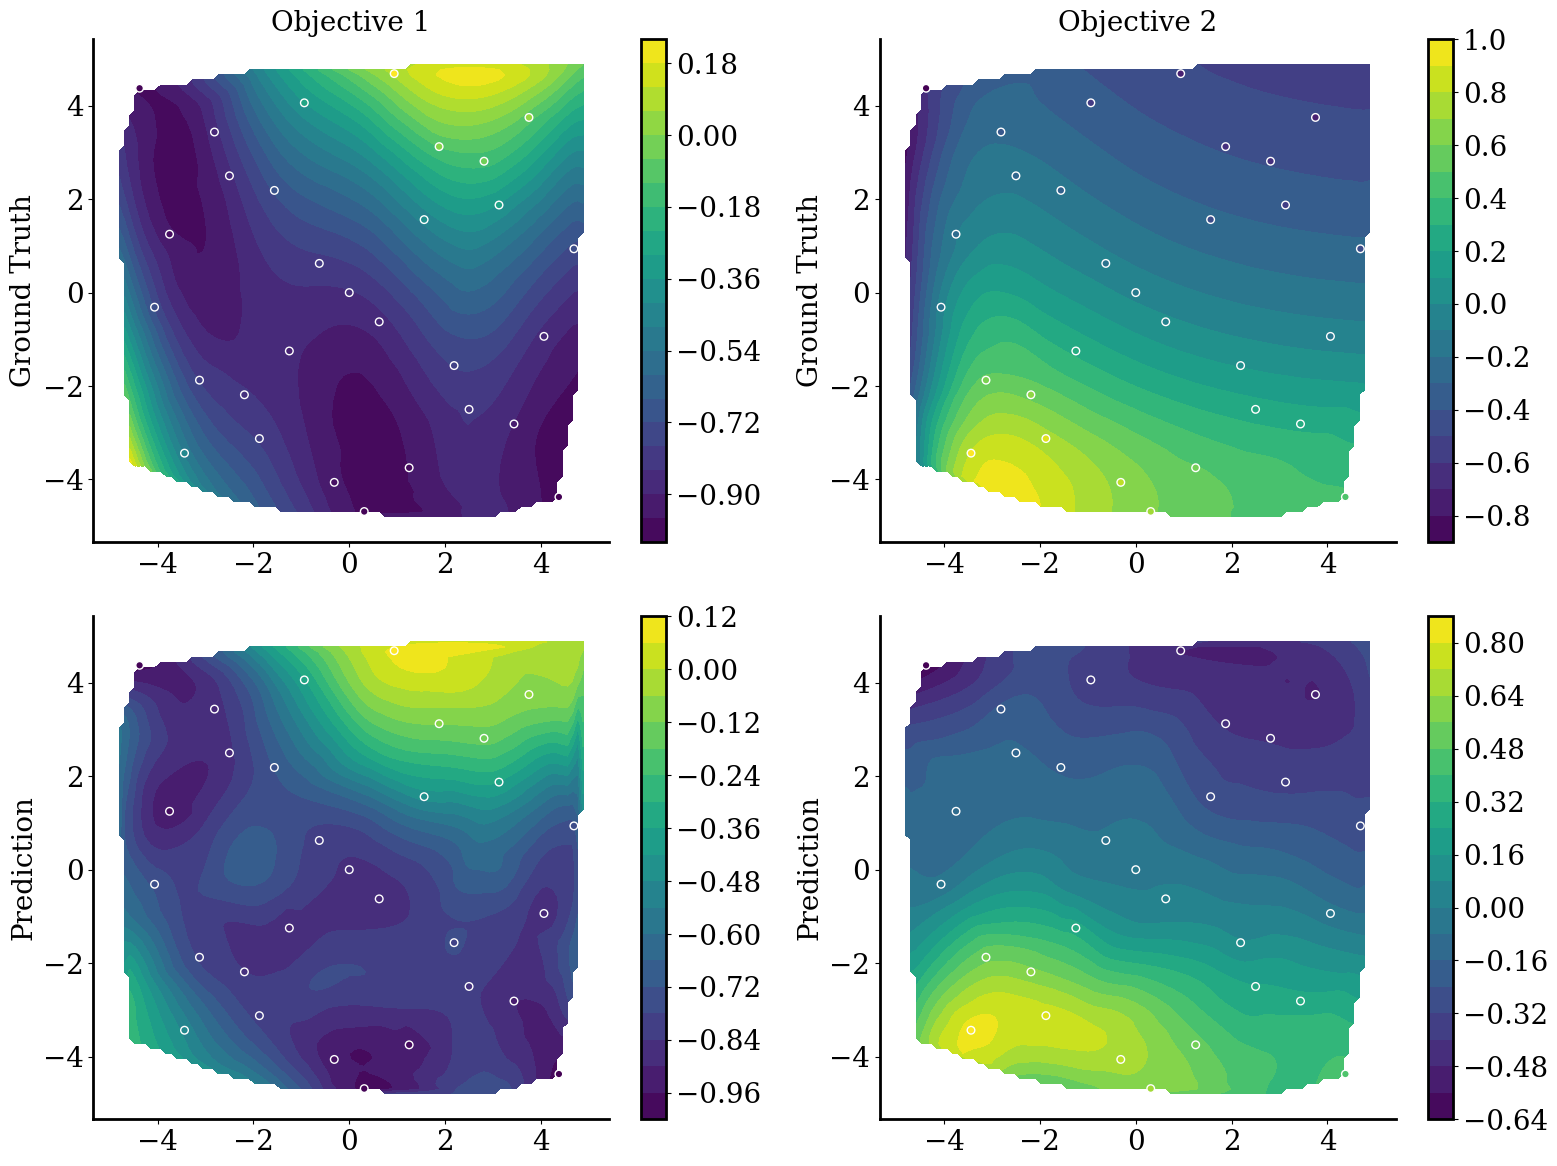

In [20]:
# Plot the ground truth and predictions with context datapoints
fig = plot_prediction(
    mean=mean,
    std=std,
    x=x_plot,
    y=y_plot_scaled,
    xctx=xc,
    yctx=yc_scaled,
    x_mask=x_mask,
    y_mask=y_mask,
    plot_mean=True,
    plot_order=False, 
)

In [21]:
# Increase the number of context 
nc = 50
xc, yc, _, _ = test_function.sample(
    input_bounds=target_input_bounds,
    batch_size=batch_size,
    num_subspace_points=nc,
    device=device,
    use_grid_sampling=True,
)

# NOTE must scale function values for tamo
yc_scaled = test_function.transform_outputs(yc, target_output_bounds)

# get predictions on current observations
out = model.predict(
    x_ctx=xc,
    y_ctx=yc_scaled,
    x_tar=x_plot,
    x_mask=x_mask.unsqueeze(0).expand(batch_size, -1),
    y_mask=y_mask.unsqueeze(0).expand(batch_size, -1),
)
mean = GMMPredictionHead.expected_value(out)
std = GMMPredictionHead.std(out)

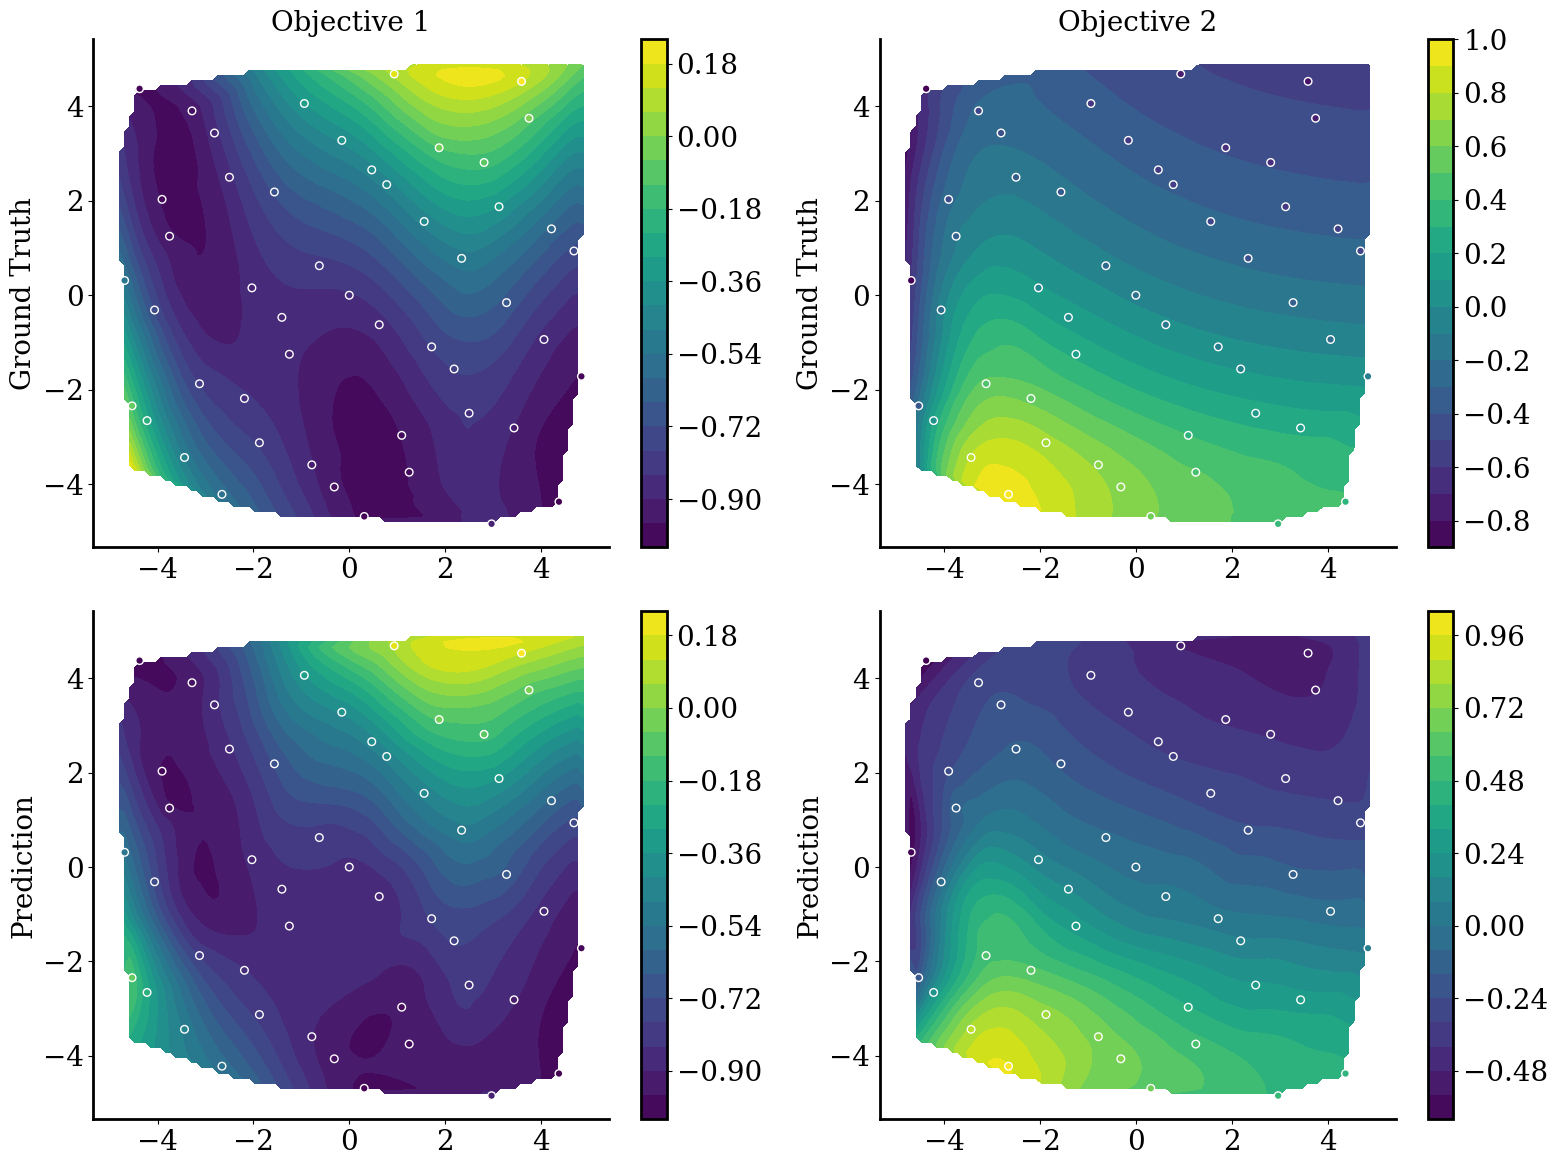

In [22]:
# Plot the ground truth and predictions with context datapoints
fig = plot_prediction(
    mean=mean,
    std=std,
    x=x_plot,
    y=y_plot_scaled,
    xctx=xc,
    yctx=yc_scaled,
    x_mask=x_mask,
    y_mask=y_mask,
    plot_mean=True,
    plot_order=False, 
)

## TAMO optimization regret plots

In [19]:
import os.path as osp

from dataclasses import asdict

import yaml
from tqdm import tqdm

from utils.dataclasses import OptimizationConfig
from utils.save import params_to_string
from utils.paths import get_filename_base, get_result_data_path


def get_config(
    config_path: str = "configs/test.yaml", new: dict = None
) -> OptimizationConfig:
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)["optimization"]

    config = OptimizationConfig(**config)
    if new:
        for k, v in new.items():
            setattr(config, k, v)
    return config


def load_data(
    config: dict,
    function_name: str,
    expid: str, 
    seed_list: list,
    metric_name: str,
    ckpt_name: str = "ckpt",
    suffix_segment: str = None,
    device="cpu",
):
    """Load data of shape [num_seed, batch_size, horizon]"""
    _filename_base = get_filename_base(
        function_name=function_name,
        ckpt_name=ckpt_name,
        suffix_segment=suffix_segment,
    )
    datapath = get_result_data_path(
        model_name="TAMO",
        expid=expid,
        task_type="optimization",
        filename_base=_filename_base,
    )
    result_folder_name = params_to_string(asdict(config))
    print(f"datapath:\t{datapath}")

    seed_not_found = []
    data_list = []
    for seed in tqdm(seed_list, desc="Loading results..."):
        seed_datapath = osp.join(
            datapath, str(seed), result_folder_name, f"{metric_name}.pt"
        )
        print(seed_datapath)
        if not osp.exists(seed_datapath):
            seed_not_found.append(seed)
            continue
        try:
            data = torch.load(seed_datapath, map_location=device)
            data_list.append(data)
        except Exception as e:
            raise RuntimeError(
                f"Error occurs when loading seed {seed} from {seed_datapath}:\n{e}"
            )

    if seed_not_found:
        print(f"Warning: results with followings seeds not found:\n{seed_not_found}")

    # [num_seeds, batch_size, horizon]
    if data_list:
        data = torch.stack(data_list, dim=0)
        return data
    else:
        return None

In [24]:
from torch import Tensor
import numpy as np
import re
import matplotlib.pyplot as plt


def plot_ax(
    config: OptimizationConfig,
    function_name: str,
    expid: str,
    seed_list: list,
    metric_name: str,
    ax = None,
    label: str = "TAMO",
    logscale: bool = False,
):
    def _transform_data(config: OptimizationConfig, metric_name: str, data: Tensor):
        if metric_name == "regret":
            # 1 + (-hv / max_hv)
            return 1 + data
        if metric_name == "time":
            # cumulative time
            return torch.cumsum(data, dim=-1)
        else:
            return data

    data = load_data(
        config=config,
        function_name=function_name,
        expid=expid,
        seed_list=seed_list,
        metric_name=metric_name,
    )
    data = _transform_data(config, metric_name, data)

    def _get_title(s: str) -> str:
        # Expected format: dx<int>_dy<int>
        pattern = re.compile(r"^dx\d+_dy\d+$", re.IGNORECASE)
        if not pattern.match(s):
            if s == "OilSorbentContinuousMid":
                s = "Oil Sorbent"
            return s

        parts = s.split("_")
        transformed_parts = [p.upper() for p in parts]
        return "GP-" + "-".join(transformed_parts)

    title = _get_title(function_name)

    def _tnp(tensor):
        if isinstance(tensor, torch.Tensor):
            return tensor.cpu().numpy()
        elif isinstance(tensor, np.ndarray):
            return tensor
        else:
            raise ValueError("Input must be a torch.Tensor or np.ndarray")

    def _plot(
        yvals: Tensor | np.ndarray,
        logscale: bool,
        ax=None,
        label: str = "TAMO",
        ylabel: str = "Value",
        xlabel: str = "Oracle Calls",
        color: str = "blue",
        linewidth: float = 4.0,
        show_title: bool = True,
        show_xlabel: bool = True,
        show_ylabel: bool = True,
    ):
        yvals = _tnp(yvals)
        N = yvals.shape[-1]

        # [B, N]
        yvals = yvals.reshape(-1, N)
        B = yvals.shape[0]

        xvals = np.array(range(N))

        means = yvals.mean(axis=0)
        stds = yvals.std(axis=0)
        cf = stds * 1.96 / np.sqrt(B)

        if ax is None:
            fig, ax = plt.subplots(1, 1, figsize=(10, 6))

        ax.fill_between(
            xvals,
            means - cf,
            means + cf,
            color=color,
            linewidth=linewidth,
            alpha=0.3,
        )
        ax.plot(xvals, means, color=color, label=label)

        ax.grid(True, alpha=0.5, linestyle="dotted")

        if logscale:
            ax.set_yscale("log")
        if show_xlabel:
            ax.set_xlabel(xlabel)
        if show_ylabel:
            ax.set_ylabel(ylabel)
        if show_title:
            ax.set_title(title)
        return ax

    ax = _plot(
        yvals=data,
        logscale=logscale,
        label=label,
        ylabel=metric_name,
        ax=ax,
    )
    return ax

datapath:	results/data/TAMO/DX12_DY123/optimization/BraninCurrin/ckpt


Loading results...:   0%|          | 0/30 [00:00<?, ?it/s]

results/data/TAMO/DX12_DY123/optimization/BraninCurrin/ckpt/0/T100_batc1_cost1e+00_cost0_dim_full_epsi0e+00_fant0_max_100_min_10_num_1_num_2048_num_1_q1_rand0_read1_regrratio_singnone_singnone_use_0_use_0_use_1_use_1_use_1_writ1/regret.pt


Loading results...: 100%|██████████| 30/30 [00:02<00:00, 13.81it/s]


results/data/TAMO/DX12_DY123/optimization/BraninCurrin/ckpt/1/T100_batc1_cost1e+00_cost0_dim_full_epsi0e+00_fant0_max_100_min_10_num_1_num_2048_num_1_q1_rand0_read1_regrratio_singnone_singnone_use_0_use_0_use_1_use_1_use_1_writ1/regret.pt
results/data/TAMO/DX12_DY123/optimization/BraninCurrin/ckpt/2/T100_batc1_cost1e+00_cost0_dim_full_epsi0e+00_fant0_max_100_min_10_num_1_num_2048_num_1_q1_rand0_read1_regrratio_singnone_singnone_use_0_use_0_use_1_use_1_use_1_writ1/regret.pt
results/data/TAMO/DX12_DY123/optimization/BraninCurrin/ckpt/3/T100_batc1_cost1e+00_cost0_dim_full_epsi0e+00_fant0_max_100_min_10_num_1_num_2048_num_1_q1_rand0_read1_regrratio_singnone_singnone_use_0_use_0_use_1_use_1_use_1_writ1/regret.pt
results/data/TAMO/DX12_DY123/optimization/BraninCurrin/ckpt/4/T100_batc1_cost1e+00_cost0_dim_full_epsi0e+00_fant0_max_100_min_10_num_1_num_2048_num_1_q1_rand0_read1_regrratio_singnone_singnone_use_0_use_0_use_1_use_1_use_1_writ1/regret.pt
results/data/TAMO/DX12_DY123/optimization/Br

Loading results...: 100%|██████████| 30/30 [00:00<00:00, 455.22it/s]

results/data/TAMO/DX12_DY123/optimization/BraninCurrin/ckpt/0/T100_batc1_cost1e+00_cost0_dim_full_epsi0e+00_fant0_max_100_min_10_num_1_num_2048_num_1_q1_rand0_read1_regrratio_singnone_singnone_use_0_use_0_use_1_use_1_use_1_writ1/time.pt
results/data/TAMO/DX12_DY123/optimization/BraninCurrin/ckpt/1/T100_batc1_cost1e+00_cost0_dim_full_epsi0e+00_fant0_max_100_min_10_num_1_num_2048_num_1_q1_rand0_read1_regrratio_singnone_singnone_use_0_use_0_use_1_use_1_use_1_writ1/time.pt
results/data/TAMO/DX12_DY123/optimization/BraninCurrin/ckpt/2/T100_batc1_cost1e+00_cost0_dim_full_epsi0e+00_fant0_max_100_min_10_num_1_num_2048_num_1_q1_rand0_read1_regrratio_singnone_singnone_use_0_use_0_use_1_use_1_use_1_writ1/time.pt
results/data/TAMO/DX12_DY123/optimization/BraninCurrin/ckpt/3/T100_batc1_cost1e+00_cost0_dim_full_epsi0e+00_fant0_max_100_min_10_num_1_num_2048_num_1_q1_rand0_read1_regrratio_singnone_singnone_use_0_use_0_use_1_use_1_use_1_writ1/time.pt
results/data/TAMO/DX12_DY123/optimization/BraninCurr

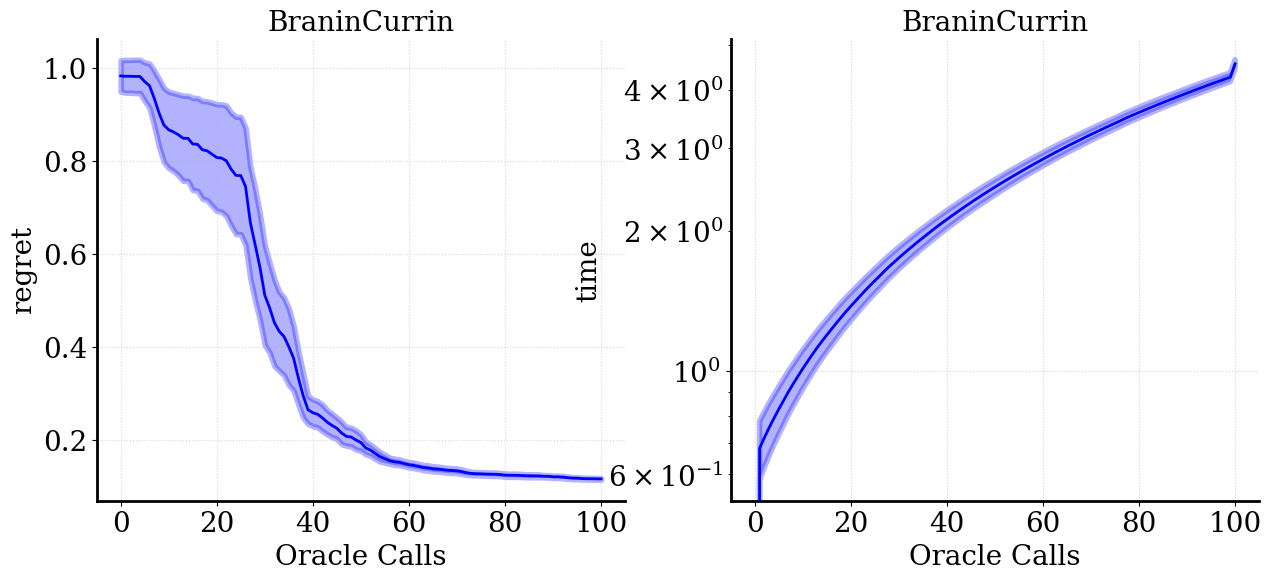

In [27]:
seed_list = list(range(30))
function_name = "BraninCurrin"
ckpt_name = "ckpt"
config = get_config()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes = axes.ravel()

plot_ax(
    ax=axes[0],
    config=config,
    function_name="BraninCurrin",
    expid=expid,
    seed_list=seed_list,
    metric_name="regret",
)

plot_ax(
    ax=axes[1],
    config=config,
    function_name="BraninCurrin",
    expid=expid,
    seed_list=seed_list,
    metric_name="time",
    logscale=True, 
)
plt.show()